In [3]:
import cupy as np
import matplotlib.pyplot as plt
import time

# =============================================================================
# Parameters (MATLAB -> Python)
# =============================================================================
Nx = 10   # number of points in x-direction
Ny = 50   # number of points in y-direction

T = 0.15
beta = 1.0 / T
t = 1.0
V = 1.5
mu = 1.8

# external field
Bx = 0.0  # off-diagonal
Bz = 0.0  # diagonal

# momentum grid (matches MATLAB linspace(pi/Ny, pi, Ny))
ky_list = np.linspace(np.pi / Ny, np.pi, Ny)

AbsTol = 1e-6
RelTol = 1e-4
maxItr = 500

# =============================================================================
# Helpers
# =============================================================================
def g(i_site: int, comp: int) -> int:
    """Global index for site i_site (0..Nx-1) and component comp (0..3)."""
    return 4 * i_site + comp

def fermi_dirac(E, beta):
    """Stable-ish Fermi-Dirac for real E."""
    x = beta * E
    return np.where(x > 50, 0.0, np.where(x < -50, 1.0, 1.0 / (np.exp(x) + 1.0)))

def build_H1(Fx_plus, Fx_min):
    """k-independent Hamiltonian (chemical potential, x-hopping, x-pairing, fields)."""
    dim = 4 * Nx
    H1 = np.zeros((dim, dim), dtype=np.complex128)

    # onsite blocks
    for i in range(Nx):
        # diagonal: chemical potential + Bz
        H1[g(i, 0), g(i, 0)] = -mu + Bz
        H1[g(i, 1), g(i, 1)] = -mu - Bz
        H1[g(i, 2), g(i, 2)] =  mu - Bz
        H1[g(i, 3), g(i, 3)] =  mu + Bz

        # Bx couplings within site block
        H1[g(i, 0), g(i, 1)] = Bx
        H1[g(i, 1), g(i, 0)] = Bx
        H1[g(i, 2), g(i, 3)] = -Bx
        H1[g(i, 3), g(i, 2)] = -Bx

    # x-direction hopping + x-pairing (between i and i+1)
    for i in range(Nx - 1):
        # hopping (same pattern as MATLAB repmat([-t,-t,t,t],..., Nx-1))
        for c, hop in enumerate([-t, -t, t, t]):
            H1[g(i, c),   g(i + 1, c)] = hop
            H1[g(i + 1, c), g(i, c)] = hop

        # superconducting off-diagonal x-terms
        Fx1 = V * Fx_min[i]
        Fx2 = V * Fx_plus[i]

        # Upper (i -> i+1)
        H1[g(i, 0), g(i + 1, 3)] =  Fx2  # (1,4)
        H1[g(i, 1), g(i + 1, 2)] = -Fx1  # (2,3)
        H1[g(i, 2), g(i + 1, 1)] = -Fx2  # (3,2)
        H1[g(i, 3), g(i + 1, 0)] =  Fx1  # (4,1)

        # Lower (i+1 -> i)
        H1[g(i + 1, 0), g(i, 3)] =  Fx1  # (1,4)
        H1[g(i + 1, 1), g(i, 2)] = -Fx2  # (2,3)
        H1[g(i + 1, 2), g(i, 1)] = -Fx1  # (3,2)
        H1[g(i + 1, 3), g(i, 0)] =  Fx2  # (4,1)

    return H1

def build_H0(Fy_plus, Fy_min):
    """k=0 terms (dispersion + onsite y-pairing with no phase)."""
    dim = 4 * Nx
    H0 = np.zeros((dim, dim), dtype=np.complex128)

    # dispersion at ky=0: epsilon = -2t*cos(0) = -2t
    for i in range(Nx):
        H0[g(i, 0), g(i, 0)] = -2 * t
        H0[g(i, 1), g(i, 1)] = -2 * t
        H0[g(i, 2), g(i, 2)] =  2 * t
        H0[g(i, 3), g(i, 3)] =  2 * t

        Fy_14 = V * (Fy_plus[i] + Fy_min[i])
        Fy_23 = -V * (Fy_plus[i] + Fy_min[i])

        H0[g(i, 0), g(i, 3)] = Fy_14
        H0[g(i, 1), g(i, 2)] = Fy_23
        H0[g(i, 2), g(i, 1)] = np.conj(Fy_23)
        H0[g(i, 3), g(i, 0)] = np.conj(Fy_14)

    return H0

def build_H2(Fy_plus, Fy_min, ky):
    """k-dependent terms for a given ky (dispersion + onsite y-pairing with phases)."""
    dim = 4 * Nx
    H2 = np.zeros((dim, dim), dtype=np.complex128)

    epsilon = -2 * t * np.cos(ky)
    e = np.exp(1j * ky)
    em = np.exp(-1j * ky)

    for i in range(Nx):
        # dispersion
        H2[g(i, 0), g(i, 0)] =  epsilon
        H2[g(i, 1), g(i, 1)] =  epsilon
        H2[g(i, 2), g(i, 2)] = -epsilon
        H2[g(i, 3), g(i, 3)] = -epsilon

        # y-pairing with phase
        Fy_14 = V * (Fy_plus[i] * em + Fy_min[i] * e)
        Fy_23 = -V * (Fy_plus[i] * e + Fy_min[i] * em)

        H2[g(i, 0), g(i, 3)] = Fy_14
        H2[g(i, 1), g(i, 2)] = Fy_23
        H2[g(i, 2), g(i, 1)] = np.conj(Fy_23)
        H2[g(i, 3), g(i, 0)] = np.conj(Fy_14)

    return H2

# =============================================================================
# Initial order parameters (MATLAB -> Python)
# =============================================================================
Fx_plus = 0.1 * np.ones(Nx - 1, dtype=np.complex128)
Fx_min  = -0.1 * np.ones(Nx - 1, dtype=np.complex128)
Fy_plus = 0.1j * np.ones(Nx, dtype=np.complex128)
Fy_min  = -0.1j * np.ones(Nx, dtype=np.complex128)

# differences + loop conditions
absdiff1 = absdiff2 = absdiff3 = absdiff4 = 100.0
reldiff1 = reldiff2 = reldiff3 = reldiff4 = 100.0
Itr = 0

c1 = True
c2 = True
c3 = True

# =============================================================================
# Iteration
# =============================================================================
t0 = time.perf_counter()

while c1 and c2 and c3:
    H1 = build_H1(Fx_plus, Fx_min)
    H0 = build_H0(Fy_plus, Fy_min)

    # Diagonalize k=0 block
    Hk0 = H0 + H1
    # (optional) symmetrize to reduce numerical drift
    Hk0 = 0.5 * (Hk0 + Hk0.conj().T)

    eigval0, eigvec0 = np.linalg.eigh(Hk0)

    u0 = eigvec0[0::4, :]
    v0 = eigvec0[1::4, :]
    w0 = eigvec0[2::4, :]
    x0 = eigvec0[3::4, :]

    Energies0 = np.tile(eigval0, (Nx, 1))
    f_E0 = fermi_dirac(Energies0, beta)
    pos_energy0 = Energies0 > 0

    # Free energy (MATLAB form)
    E_n0 = eigval0 * (eigval0 > 0)
    Free = -np.sum(E_n0) / 2.0 - np.sum(np.log(1.0 + np.exp(-beta * E_n0))) / beta

    # Pair correlations (k=0), filtered to positive energies as in MATLAB
    Fx0_ux1 = u0[:-1, :] * np.conj(x0[1:, :]) * (1 - f_E0[:-1, :]) * pos_energy0[:-1, :]
    Fx0_ux2 = u0[1:, :]  * np.conj(x0[:-1, :]) * (1 - f_E0[1:, :])  * pos_energy0[1:, :]
    Fx0_vw1 = v0[:-1, :] * np.conj(w0[1:, :]) * (f_E0[1:, :])       * pos_energy0[1:, :]
    Fx0_vw2 = v0[1:, :]  * np.conj(w0[:-1, :]) * (f_E0[:-1, :])    * pos_energy0[:-1, :]

    Fy0_ux = u0 * np.conj(x0) * (1 - f_E0) * pos_energy0
    Fy0_vw = v0 * np.conj(w0) * (f_E0)     * pos_energy0

    # initialise "new" OPs with k=0 contribution (dividing by Ny as in MATLAB)
    Fx_plus_new = np.sum(Fx0_ux1 + Fx0_vw2, axis=1) / Ny
    Fx_min_new  = np.sum(Fx0_ux2 + Fx0_vw1, axis=1) / Ny
    K_y0        = np.sum(Fy0_ux + Fy0_vw,   axis=1) / Ny
    Fy_plus_new = K_y0.copy()
    Fy_min_new  = K_y0.copy()

    # singlet/triplet initial components
    FS_x = np.sum(Fx0_ux1 + Fx0_ux2 + Fx0_vw1 + Fx0_vw2, axis=1) / (2 * Ny)
    FS_y = K_y0.copy()

    FT_x_plus = np.sum(Fx0_ux1 - Fx0_ux2 + Fx0_vw2 - Fx0_vw1, axis=1) / (2 * Ny)
    FT_x_min  = np.sum(Fx0_ux2 - Fx0_ux1 + Fx0_vw1 - Fx0_vw2, axis=1) / (2 * Ny)
    FT_y_plus = np.zeros(Nx, dtype=np.complex128)
    FT_y_min  = np.zeros(Nx, dtype=np.complex128)

    # ky loop
    for ky in ky_list:
        H2 = build_H2(Fy_plus, Fy_min, ky)
        H = H1 + H2
        H = 0.5 * (H + H.conj().T)

        eigval, eigvec = np.linalg.eigh(H)

        u = eigvec[0::4, :]
        v = eigvec[1::4, :]
        w = eigvec[2::4, :]
        x = eigvec[3::4, :]

        Energies = np.tile(eigval, (Nx, 1))
        f_E = fermi_dirac(Energies, beta)

        # Free energy update (matches MATLAB code)
        Free = Free - np.sum(eigval) / 2.0 - np.sum(np.log(1.0 + np.exp(-beta * eigval))) / beta

        # Pair correlations (no positive-energy filter here, as in MATLAB)
        Fx_ux1 = u[:-1, :] * np.conj(x[1:, :]) * (1 - f_E[:-1, :])
        Fx_ux2 = u[1:, :]  * np.conj(x[:-1, :]) * (1 - f_E[1:, :])
        Fx_vw1 = v[:-1, :] * np.conj(w[1:, :]) * (f_E[1:, :])
        Fx_vw2 = v[1:, :]  * np.conj(w[:-1, :]) * (f_E[:-1, :])

        Fy_ux = u * np.conj(x) * (1 - f_E)
        Fy_vw = v * np.conj(w) * (f_E)

        e = np.exp(1j * ky)
        em = np.exp(-1j * ky)

        Fx_plus_new += np.sum(Fx_ux1 + Fx_vw2, axis=1) / Ny
        Fx_min_new  += np.sum(Fx_ux2 + Fx_vw1, axis=1) / Ny
        Fy_plus_new += np.sum(Fy_ux * e  + Fy_vw * em, axis=1) / Ny
        Fy_min_new  += np.sum(Fy_ux * em + Fy_vw * e,  axis=1) / Ny

        FS_x += np.sum(Fx_ux1 + Fx_ux2 + Fx_vw1 + Fx_vw2, axis=1) / (2 * Ny)
        FS_y += np.sum(Fy_ux + Fy_vw, axis=1) * np.cos(ky) / Ny

        FT_x_plus += np.sum(Fx_ux1 - Fx_ux2 + Fx_vw2 - Fx_vw1, axis=1) / (2 * Ny)
        FT_x_min  += np.sum(Fx_ux2 - Fx_ux1 + Fx_vw1 - Fx_vw2, axis=1) / (2 * Ny)
        FT_y_plus += 1j * np.sum(Fy_ux - Fy_vw, axis=1) * np.sin(ky) / Ny
        FT_y_min  += -1j * np.sum(Fy_ux - Fy_vw, axis=1) * np.sin(ky) / Ny

    # Filter s, d, px, py
    F_swave = (np.r_[0, FS_x] + np.r_[FS_x, 0] + 2 * FS_y) / 4.0
    F_dwave = (np.r_[0, FS_x] + np.r_[FS_x, 0] - 2 * FS_y) / 4.0
    F_px    = (np.r_[0, FT_x_plus] - np.r_[FT_x_min, 0]) / 2.0
    F_py    = (FT_y_plus - FT_y_min) / 2.0

    # Convergence metrics
    absdiff1 = np.linalg.norm(Fx_plus_new - Fx_plus)
    absdiff2 = np.linalg.norm(Fx_min_new  - Fx_min)
    absdiff3 = np.linalg.norm(Fy_plus_new - Fy_plus)
    absdiff4 = np.linalg.norm(Fy_min_new  - Fy_min)

    # avoid divide-by-zero blow-ups
    eps = 1e-15
    reldiff1 = np.linalg.norm((Fx_plus_new - Fx_plus) / (Fx_plus + eps))
    reldiff2 = np.linalg.norm((Fx_min_new  - Fx_min)  / (Fx_min  + eps))
    reldiff3 = np.linalg.norm((Fy_plus_new - Fy_plus) / (Fy_plus + eps))
    reldiff4 = np.linalg.norm((Fy_min_new  - Fy_min)  / (Fy_min  + eps))

    # update OPs
    Fx_plus = Fx_plus_new
    Fx_min  = Fx_min_new
    Fy_plus = Fy_plus_new
    Fy_min  = Fy_min_new
    Itr += 1

    # Free energy constant offsets (as in MATLAB code: done inside loop)
    E_V = -V * np.sum(np.abs(Fx_plus) ** 2 + np.abs(Fx_min) ** 2) \
          -V * np.sum(np.abs(Fy_plus) ** 2 + np.abs(Fy_min) ** 2)
    Free = Free + E_V

    if Itr == maxItr:
        print(f"Warning: Maximum number of iterations reached at T = {T}")

    c1 = (absdiff1 > AbsTol) or (absdiff2 > AbsTol) or (absdiff3 > AbsTol) or (absdiff4 > AbsTol)
    c2 = (reldiff1 > RelTol) or (reldiff2 > RelTol) or (reldiff3 > RelTol) or (reldiff4 > RelTol)
    c3 = Itr < maxItr

t1 = time.perf_counter()
print(f"Elapsed time: {t1 - t0:.3f} s")

print(f"OP of p_x is {F_px[int(round(Nx/2)) - 1]}")
print(f"The free energy is {Free}")


Elapsed time: 89.627 s
OP of p_x is (0.1078526860538901+0j)
The free energy is -2319.93546714573


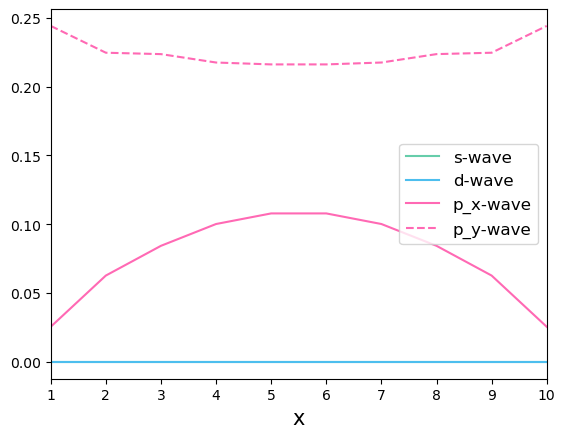

In [5]:
# =============================================================================
# Plot (MATLAB -> matplotlib)
# =============================================================================
color1 = (0.3010, 0.7450, 0.9330)
color2 = (255/255, 105/255, 180/255)
color3 = (102/255, 205/255, 170/255)

x = np.asnumpy(np.arange(1, Nx + 1))

plt.figure()
plt.plot(x, np.asnumpy(np.real(F_swave)), color=color3, label="s-wave")
plt.plot(x, np.asnumpy(np.real(F_dwave)), color=color1, label="d-wave")
plt.plot(x, np.asnumpy(np.real(F_px)),    color=color2, label="p_x-wave")
plt.plot(x, np.asnumpy(np.imag(F_py)),    "--", color=color2, label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, Nx)
plt.legend(fontsize=12, loc="best")
plt.show()

x1 = np.arange(1.5, Nx - 0.5 + 1e-12, 1.0)  # matches MATLAB: 1.5:Nx-0.5